# 📓 KNN con diferentes distancias y visualización

En este notebook aprenderás:
- Qué es KNN
- Cómo cambian las distancias
- Cómo elegir el mejor K
- Visualizar fronteras de decisión

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import Counter 

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


## 📊 Cargar dataset

In [2]:
iris = load_iris()
X = iris.data[:, :2]  # solo 2 features para graficar
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## KNN Manual, intuición matemática

In [ ]:
def knn_manual(X, y, x_new, k=3):
# Crea la función

y_pred = np.array([knn_manual(X_train, y_train, x, k=3) for x in X_test])

print(y_pred)

[1 0 2 1 1 0 1 2 1 2 2 0 0 0 0 2 2 1 2 2 0 1 0 2 2 1 2 2 0 0]


In [12]:
#Ahora creemos una clase para poder usarla

class KNNManual:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def _predecir_uno(self, x_new):
        distances = np.sqrt(np.sum((self.X_train - x_new)**2, axis=1))
        k_idx     = np.argsort(distances)[:self.k]
        k_labels  = self.y_train[k_idx]
        clases, conteos = np.unique(k_labels, return_counts=True)
        return clases[np.argmax(conteos)]

    def predict(self, X):
        return np.array([self._predecir_uno(x) for x in X])

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

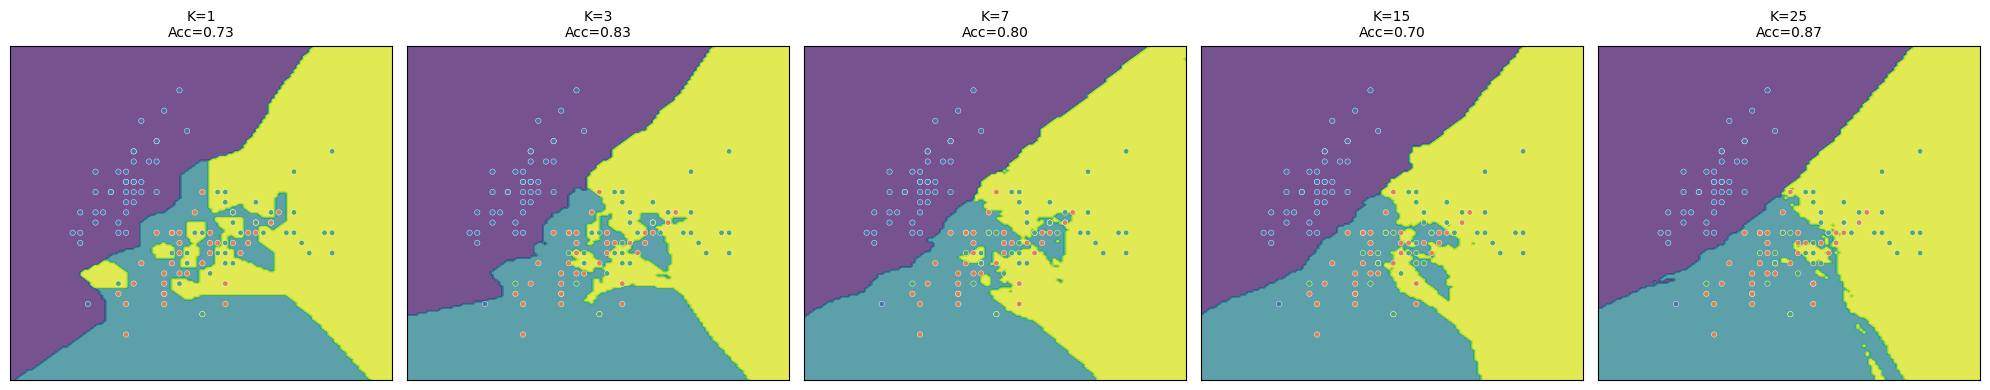

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
COLORS     = ['#4C72B0', '#DD8452', '#55A868']

for ax, k in zip(axes, [1, 3, 7, 15, 25]):
    knn = KNNManual(k=k)
    knn.fit(X_train, y_train)

    h = 0.05
    x0_min, x0_max = X_train[:,0].min()-1, X_train[:,0].max()+1
    x1_min, x1_max = X_train[:,1].min()-1, X_train[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.75)
    ax.scatter(X_train[:,0], X_train[:,1], c=[COLORS[c] for c in y_train],
               s=15, edgecolors='white', linewidths=0.3)

    acc = knn.score(X_test, y_test)
    ax.set_title(f'K={k}\nAcc={acc:.2f}', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

## 📏 Entrenar modelos con diferentes distancias

In [3]:
metrics = ['euclidean', 'manhattan', 'cosine']

for metric in metrics:
    model = KNeighborsClassifier(n_neighbors=5, metric=metric)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{metric}:", accuracy_score(y_test, preds))


euclidean: 0.7666666666666667
manhattan: 0.7666666666666667
cosine: 0.7333333333333333


## 🔍 Encontrar mejor K

In [4]:
param_grid = {
    'n_neighbors': np.arange(1, 21),
    'metric': ['euclidean', 'manhattan', 'cosine']
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print('Mejores parámetros:', grid.best_params_)


Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': np.int64(18)}


## 📈 Visualización de frontera de decisión

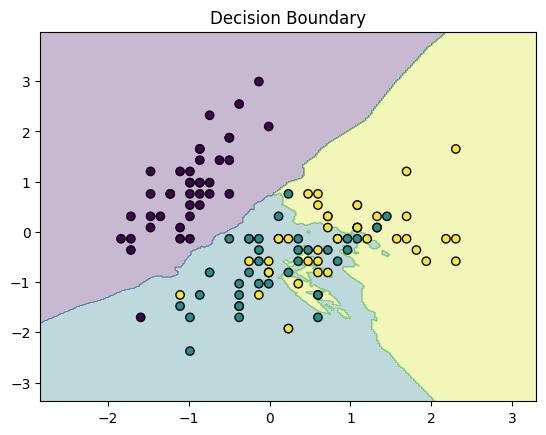

In [5]:
def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title('Decision Boundary')
    plt.show()

best_model = grid.best_estimator_
plot_decision_boundary(best_model, X_train, y_train)


## 📌 Aplicaciones de KNN

- Sistemas de recomendación
- Clasificación de imágenes
- Detección de fraude
- NLP (clasificación de texto)

### ⚠️ Limitaciones
- No escala bien
- Sensible al escalado
- Lento en predicción

### 🤖 Modelos relacionados
- K-Means
- DBSCAN
- Nearest Centroid
- Approximate Nearest Neighbors
